In [1]:
import numpy as np
import pandas as pd

from purchasing_intent import config, data as data_io, features, persistence, plots_mpl, thresholds
from purchasing_intent.evaluate import best_configuration, run_ablation, run_grid
from purchasing_intent.models import classifier_registry, positive_class_weight, sampler_registry
from purchasing_intent.pipeline import build_pipeline
from purchasing_intent.tuning import tune_random_forest
from sklearn.model_selection import train_test_split

%matplotlib inline

pd.set_option("display.width", 160)
config.IMG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
data, metadata = data_io.fetch_dataset()
data.info()

Loaded cached dataset from data/cache/uci_468.joblib
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non

In [3]:
print(data[config.TARGET].value_counts().to_string())

neg, pos = np.bincount(data[config.TARGET])
print(f"\nMinority class at \033[31m{100 * pos / (neg + pos):.2f}%\033[0m of total")
print(f"A majority-class predictor would score \033[32m{100 * neg / (neg + pos):.2f}%\033[0m accuracy")

Revenue
False    10422
True      1908

Minority class at 15.47% of total
A majority-class predictor would score 84.53% accuracy


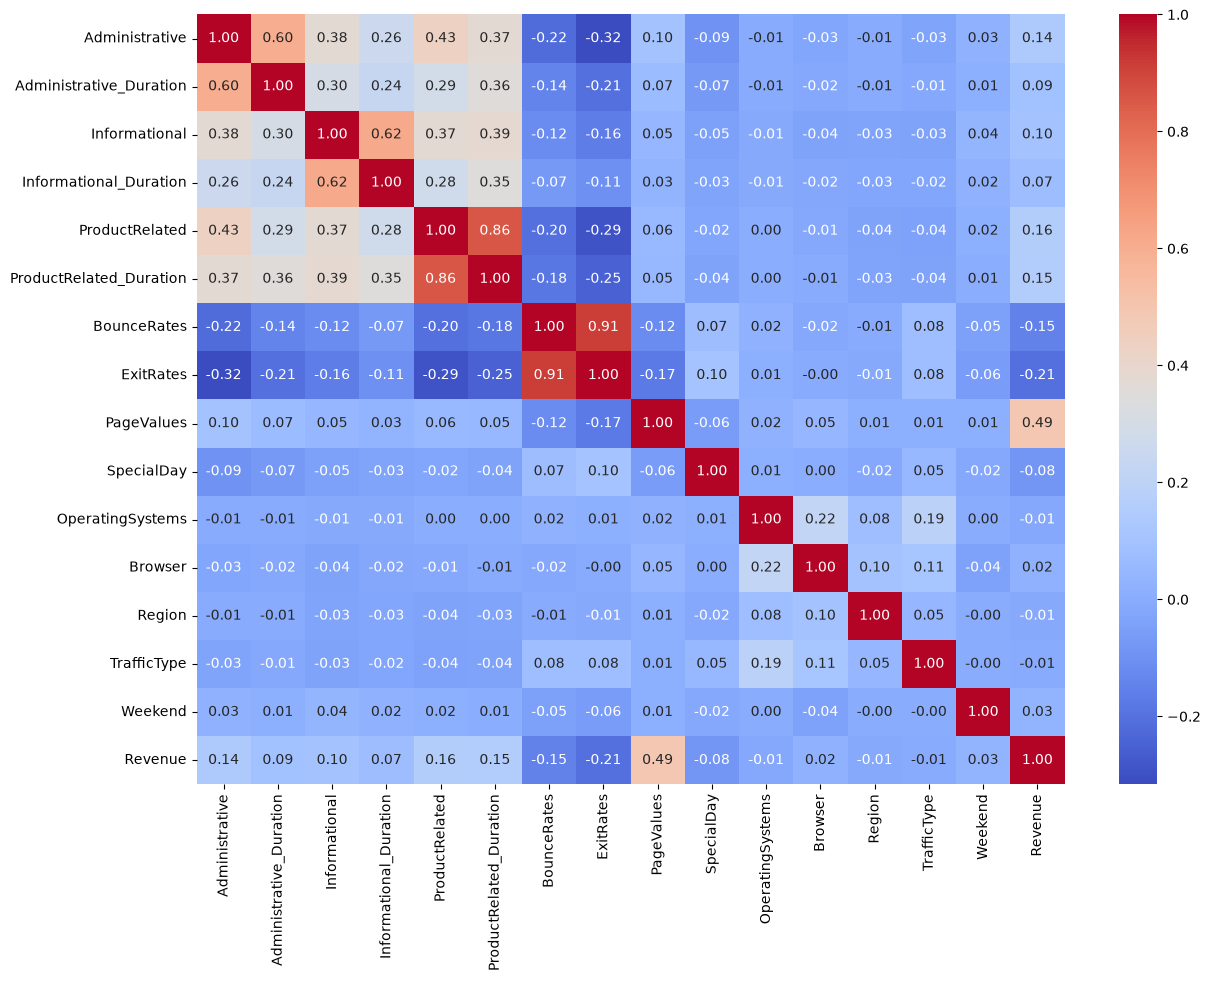

In [4]:
corr = features.correlation_matrix(data)
fig = plots_mpl.correlation_heatmap(corr, config.IMG_DIR / "heatmap1.png", close=False)

In [5]:
data = features.engineer_features(data)
print(data.isnull().sum().to_string())

SessionDuration              0
AdministrativeAvgDuration    0
Administrative               0
Administrative_Duration      0
InformationalAvgDuration     0
Informational                0
Informational_Duration       0
ProductRelatedAvgDuration    0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                    0
PageValues                   0
SpecialDay                   0
Month                        0
OperatingSystems             0
Browser                      0
Region                       0
TrafficType                  0
VisitorType                  0
Weekend                      0
Revenue                      0


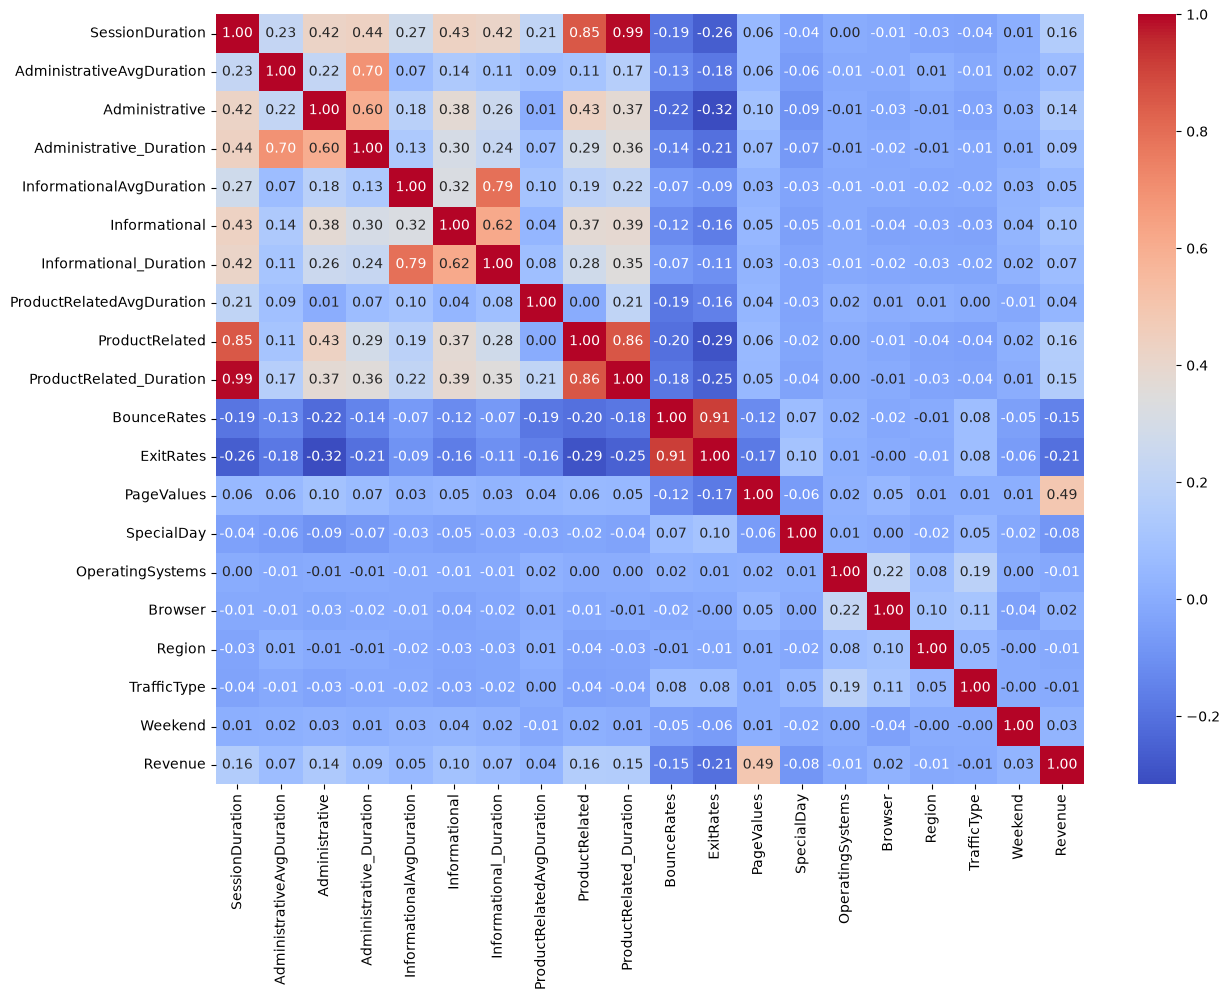

In [6]:
corr = features.correlation_matrix(data)
fig = plots_mpl.correlation_heatmap(corr, config.IMG_DIR / "heatmap2.png", close=False)

In [7]:
high_corr = features.detect_correlated(corr)
print(f"|r| > 0.9 scan returns: \033[33m{sorted(high_corr)}\033[0m")
print(f"config.CORRELATED_DROP drops: \033[33m{sorted(config.CORRELATED_DROP)}\033[0m")
print(f"The two lists differ by \033[33m{sorted(set(config.CORRELATED_DROP) - set(high_corr))}\033[0m")

|r| > 0.9 scan returns: ['ExitRates', 'ProductRelated_Duration']
config.CORRELATED_DROP drops: ['Administrative', 'Administrative_Duration', 'ExitRates', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration']
The two lists differ by ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated']


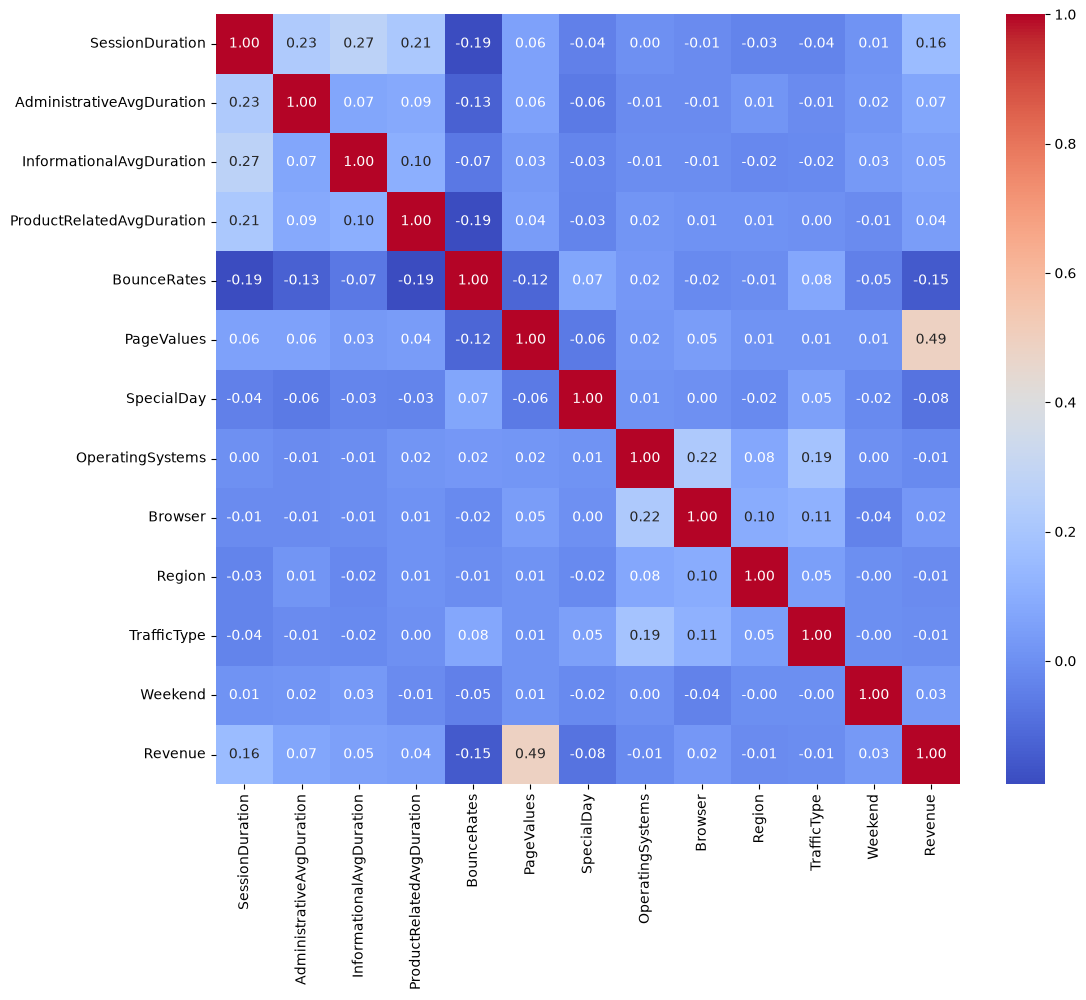

In [8]:
data = features.eliminate_correlated(data)

corr = features.correlation_matrix(data)
fig = plots_mpl.correlation_heatmap(corr, config.IMG_DIR / "heatmap3.png", figsize=config.HEATMAP_FIGSIZE_REDUCED, close=False)

In [9]:
data_io.write_raw(data)
print(f"wrote {config.display_path(config.RAW_CSV)} shape \033[36m{data.shape}\033[0m")

wrote data/raw.csv shape (12330, 15)


In [10]:
data = features.encode(data)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 66 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   SessionDuration                12330 non-null  float64
 1   AdministrativeAvgDuration      12330 non-null  float64
 2   InformationalAvgDuration       12330 non-null  float64
 3   ProductRelatedAvgDuration      12330 non-null  float64
 4   BounceRates                    12330 non-null  float64
 5   PageValues                     12330 non-null  float64
 6   SpecialDay                     12330 non-null  float64
 7   Weekend                        12330 non-null  int64  
 8   Revenue                        12330 non-null  int64  
 9   Month_Dec                      12330 non-null  int64  
 10  Month_Feb                      12330 non-null  int64  
 11  Month_Jul                      12330 non-null  int64  
 12  Month_June                     12330 non-null  int64  
 1

In [11]:
demo_X = data.drop(config.TARGET, axis=1)
demo_y = data[config.TARGET]
demo_Xtr, demo_Xte, demo_ytr, demo_yte = train_test_split(
    demo_X, demo_y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=demo_y
)

demo_pipe = build_pipeline(classifier_registry()["RandomForest"], sampler=sampler_registry()["oversampling"])
print(demo_pipe)

demo_pipe.fit(demo_Xtr, demo_ytr)
scaler = demo_pipe.named_steps["scaler"].named_transformers_["scale"]
continuous = list(demo_Xtr.select_dtypes(include=config.CONTINUOUS_DTYPE_INCLUDE).columns)

train_means = demo_Xtr[continuous].mean().to_numpy()
full_means = demo_X[continuous].mean().to_numpy()

print(f"\nscaler learned means == TRAIN means : {np.allclose(scaler.mean_, train_means)}")
print(f"scaler learned means == FULL  means : {np.allclose(scaler.mean_, full_means)}")
print(f"largest train vs. full gap: {float(np.abs(train_means - full_means).max())} units")

Pipeline(steps=[('scaler',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x125fb9b80>)],
                                   verbose_feature_names_out=False)),
                ('selector', 'passthrough'),
                ('sampler', RandomOverSampler(random_state=42)),
                ('clf', RandomForestClassifier(random_state=42))])

scaler learned means == TRAIN means : True
scaler learned means == FULL  means : False
largest train vs. full gap: 7.659907635564423 units


In [12]:
X = data.drop(config.TARGET, axis=1)
y = data[config.TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=y)

print(f"Train set shape: \033[36m{X_train.shape}\033[0m")
print(f"Test set shape: \033[36m{X_test.shape}\033[0m")
print(f"Positive rate: train \033[36m{y_train.mean():.4f}\033[0m, test \033[36m{y_test.mean():.4f}\033[0m")

Train set shape: (9864, 65)
Test set shape: (2466, 65)
Positive rate: train 0.1547, test 0.1549


KNN evaluating...
KNN / class_weighted: N/A (no class-weight mechanism)
KNN finished in 0.49 seconds

  Model SamplingTechnique  Accuracy  Precision    Recall  F1-Score       AUC
0   KNN              base  0.873479   0.671569  0.358639  0.467577  0.791592
1   KNN      oversampling  0.791160   0.395604  0.659686  0.494603  0.780355
2   KNN     undersampling  0.787105   0.401107  0.759162  0.524887  0.825510
SVM evaluating...
SVM finished in 43.76 seconds

  Model SamplingTechnique  Accuracy  Precision    Recall  F1-Score       AUC
3   SVM              base  0.884428   0.697959  0.447644  0.545455  0.884907
4   SVM      oversampling  0.862936   0.540590  0.767016  0.634199  0.899006
5   SVM     undersampling  0.847526   0.505068  0.782723  0.613963  0.891359
6   SVM    class_weighted  0.884023   0.651899  0.539267  0.590258  0.899097
LogisticRegression evaluating...
LogisticRegression finished in 0.47 seconds

                 Model SamplingTechnique  Accuracy  Precision    Recall  F1-Sc

,Model,SamplingTechnique,Accuracy,Precision,Recall,F1-Score,AUC
12,RandomForest,oversampling,0.8966,0.6693,0.6571,0.6631,0.9190
14,RandomForest,class_weighted,0.8865,0.6170,0.7042,0.6577,0.9219
16,XGBoost,oversampling,0.8775,0.5885,0.6963,0.6379,0.9174
18,XGBoost,class_weighted,0.8767,0.5859,0.6963,0.6364,0.9139
4,SVM,oversampling,0.8629,0.5406,0.7670,0.6342,0.8990
15,XGBoost,base,0.8925,0.6822,0.5733,0.6230,0.9147
13,RandomForest,undersampling,0.8406,0.4917,0.8482,0.6225,0.9190
11,RandomForest,base,0.8982,0.7399,0.5288,0.6168,0.9182
5,SVM,undersampling,0.8475,0.5051,0.7827,0.6140,0.8914
8,LogisticRegression,oversampling,0.8540,0.5203,0.7382,0.6104,0.8958


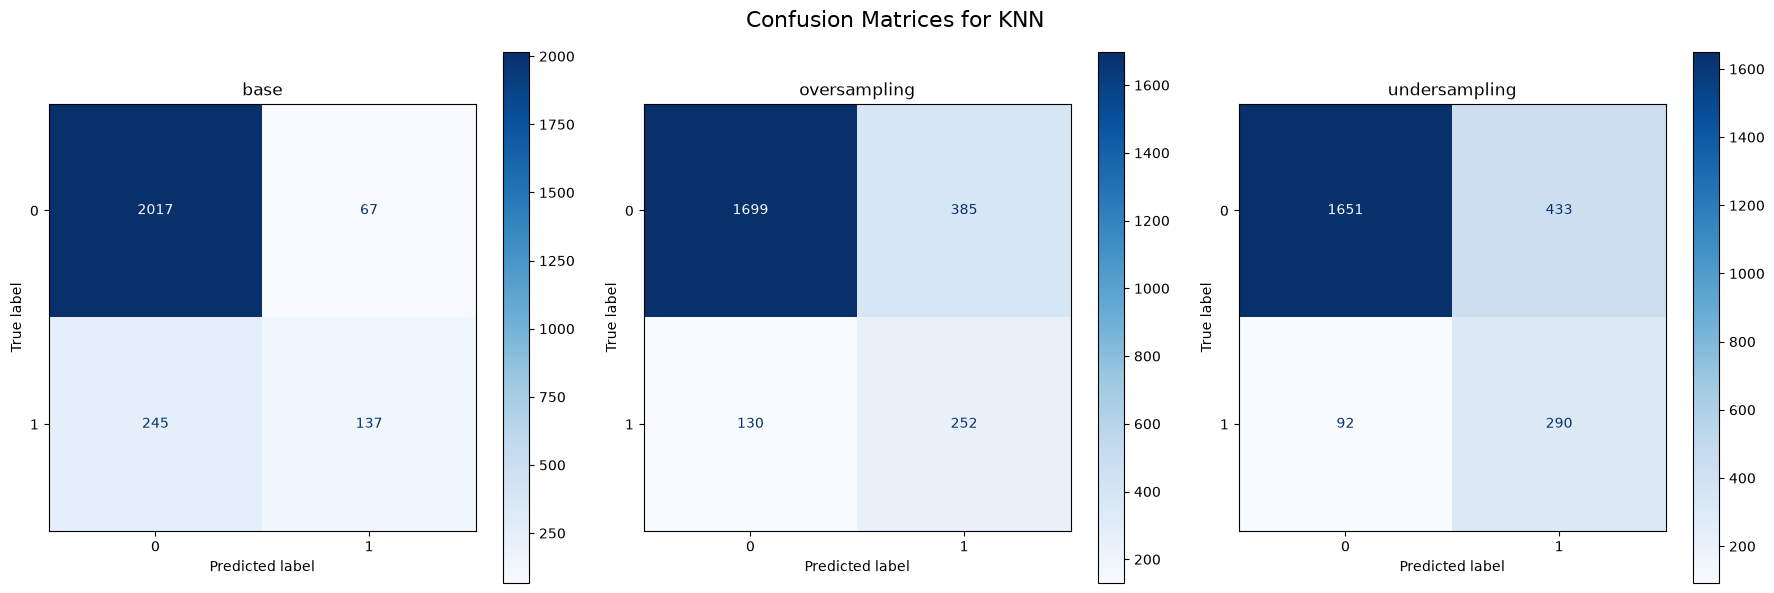

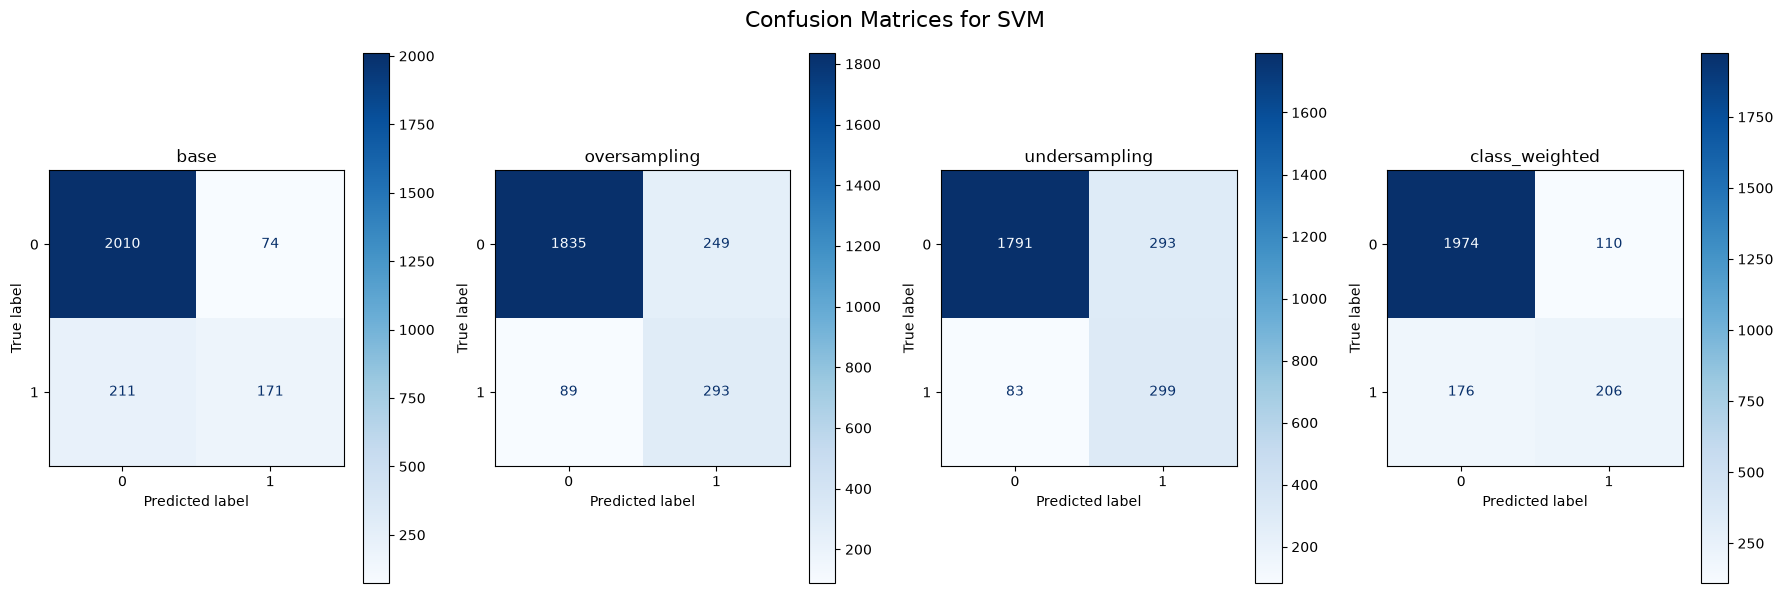

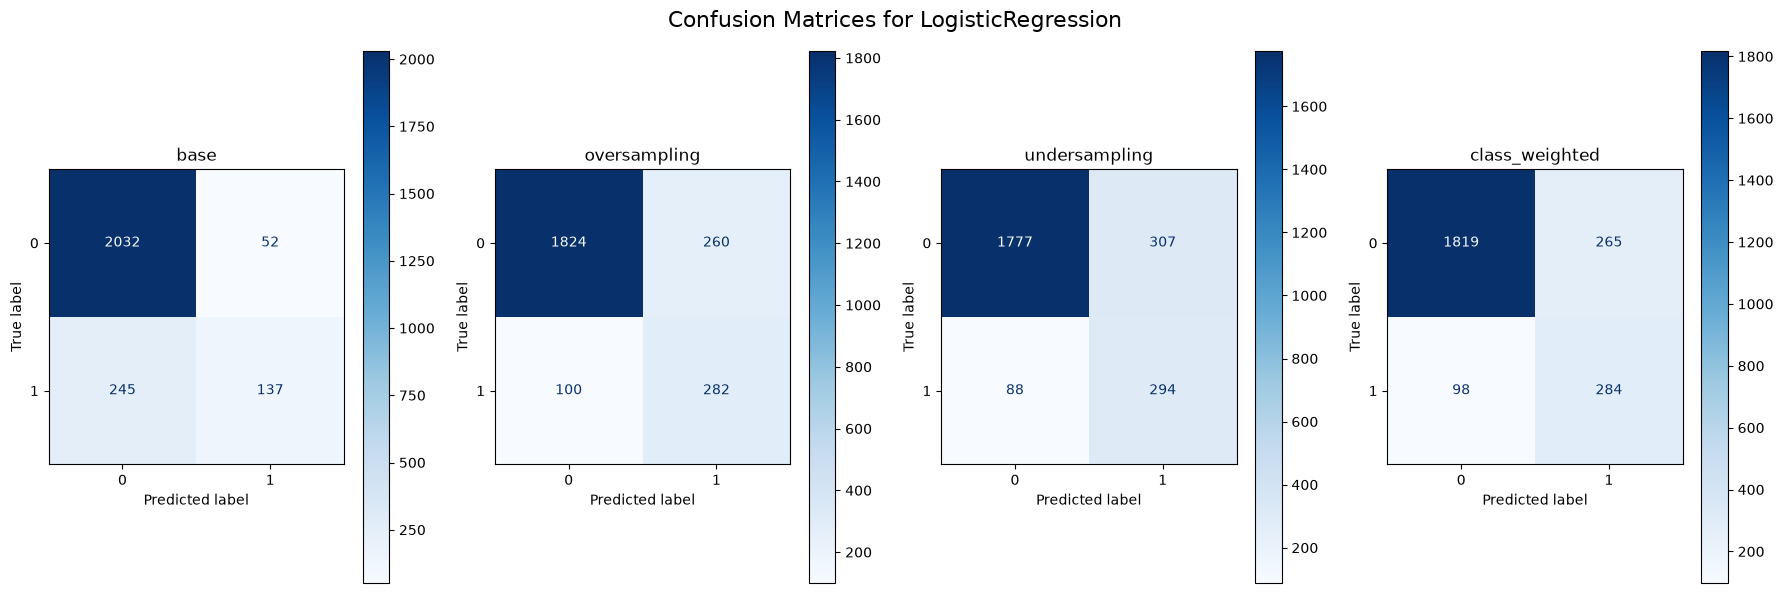

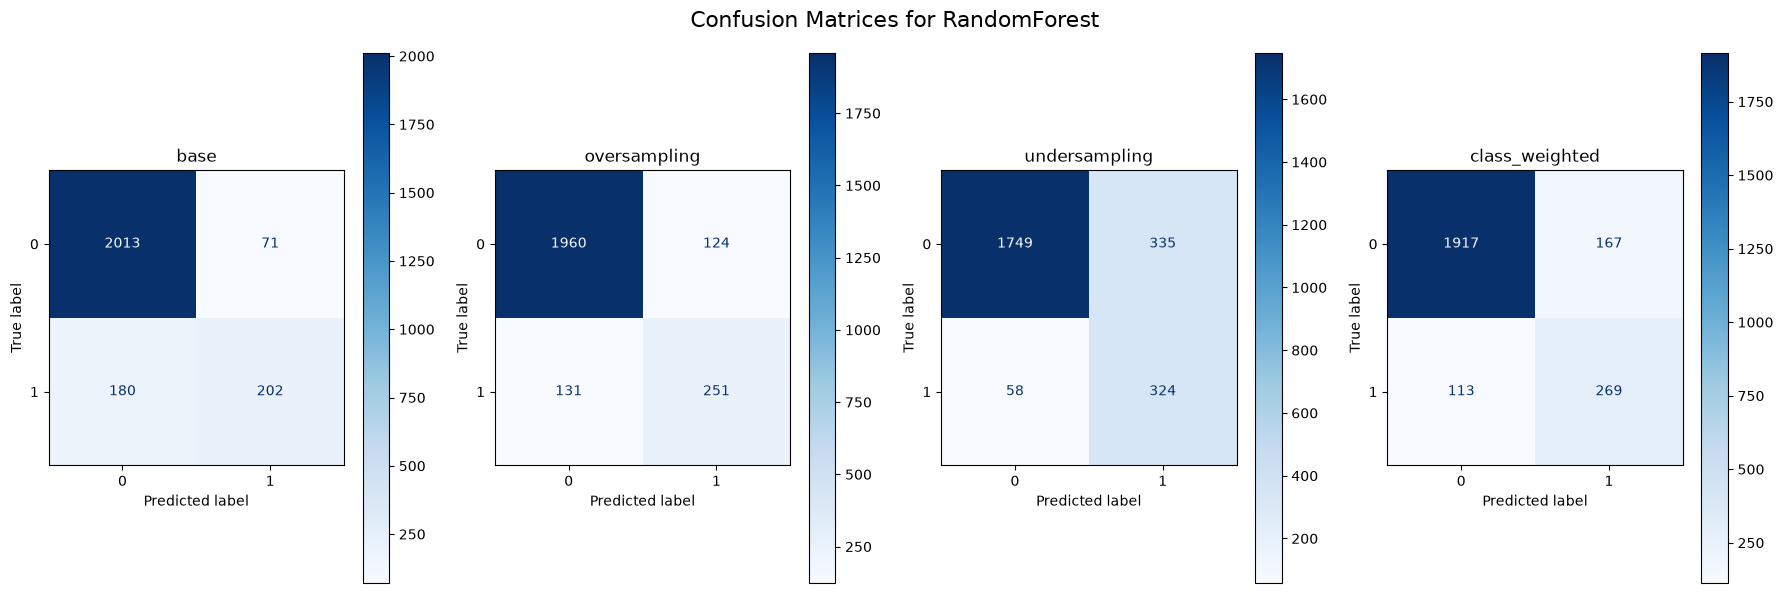

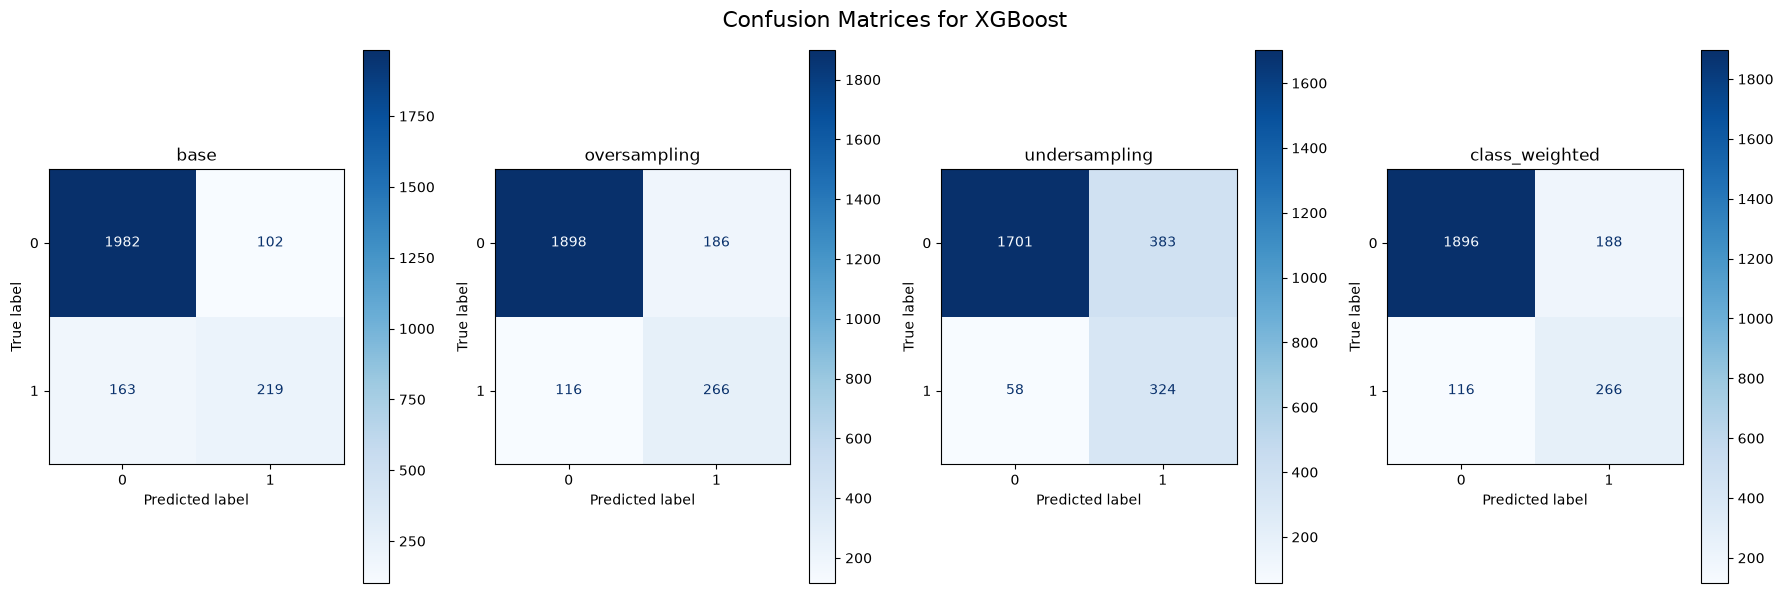

In [13]:
results = run_grid(
    X_train, X_test, y_train, y_test, tag=config.FULL_TAG, csv_path=config.RESULTS_FULL_CSV,
    close=False, display_full=False,
)
results.drop(["FPR", "TPR"], axis=1).sort_values("F1-Score", ascending=False).round(4)

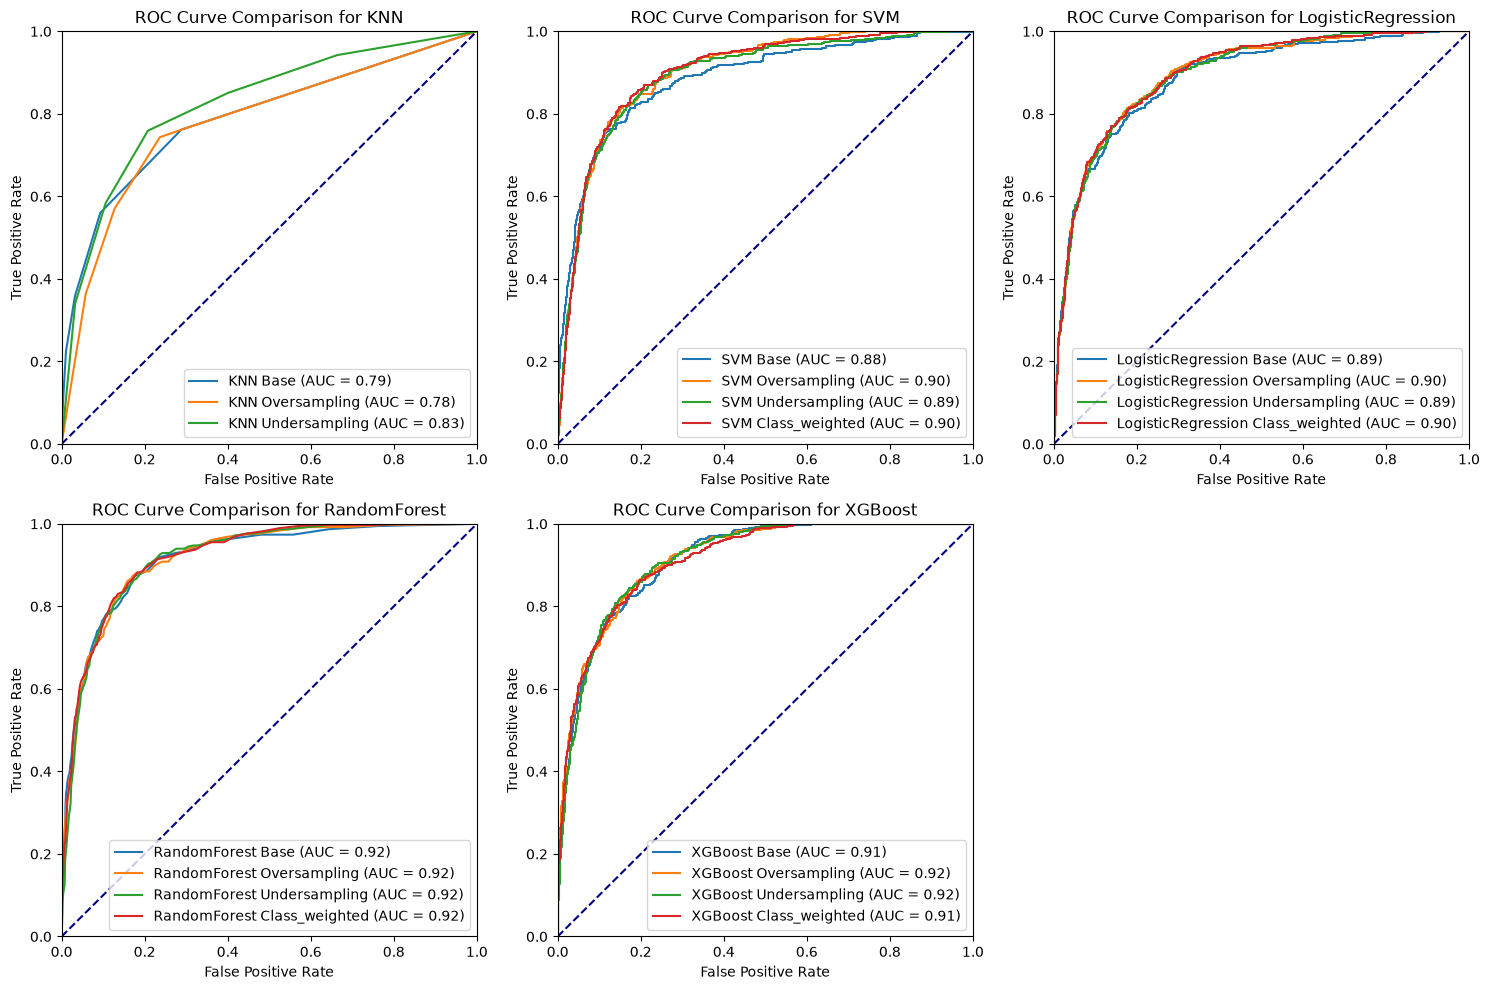

In [14]:
fig = plots_mpl.sampling_comparison(results, plot=False, close=False)
fig.savefig(config.IMG_DIR / "roc_sampling_comparison.png")

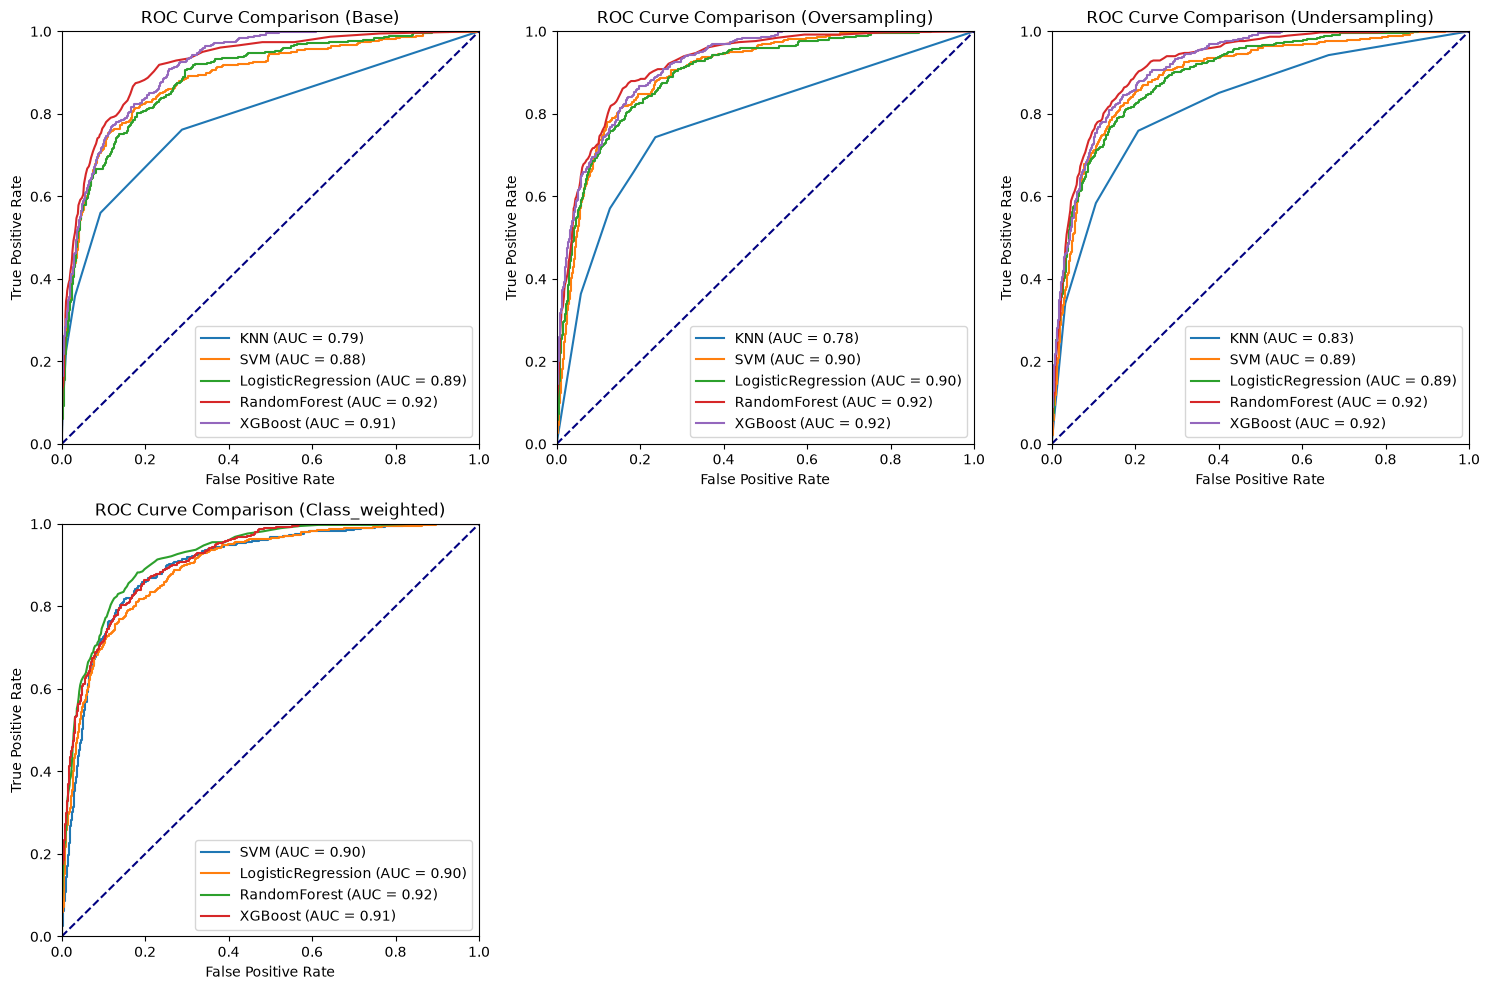

In [15]:
fig = plots_mpl.model_comparison(results, plot=False, close=False)
fig.savefig(config.IMG_DIR / "roc_model_comparison.png")

KNN evaluating...
KNN / class_weighted: N/A (no class-weight mechanism)
KNN finished in 0.37 seconds

  Model SamplingTechnique  Accuracy  Precision    Recall  F1-Score       AUC
0   KNN              base  0.886456   0.668874  0.528796  0.590643  0.850643
1   KNN      oversampling  0.818735   0.450077  0.767016  0.567280  0.836982
2   KNN     undersampling  0.811436   0.440288  0.801047  0.568245  0.871983
SVM evaluating...
SVM finished in 23.09 seconds

  Model SamplingTechnique  Accuracy  Precision    Recall  F1-Score       AUC
3   SVM              base  0.889294   0.715415  0.473822  0.570079  0.887945
4   SVM      oversampling  0.859692   0.531469  0.795812  0.637317  0.889017
5   SVM     undersampling  0.856448   0.524390  0.787958  0.629707  0.887785
6   SVM    class_weighted  0.884023   0.630435  0.607330  0.618667  0.890859
LogisticRegression evaluating...
LogisticRegression finished in 0.43 seconds

                 Model SamplingTechnique  Accuracy  Precision    Recall  F1-Sc

,Model,SamplingTechnique,Accuracy,Precision,Recall,F1-Score,AUC
14,RandomForest,class_weighted,0.8788,0.5881,0.7251,0.6495,0.9124
18,XGBoost,class_weighted,0.8763,0.5791,0.7382,0.6490,0.9140
12,RandomForest,oversampling,0.8865,0.6275,0.6571,0.6419,0.9066
4,SVM,oversampling,0.8597,0.5315,0.7958,0.6373,0.8890
5,SVM,undersampling,0.8564,0.5244,0.7880,0.6297,0.8878
11,RandomForest,base,0.8921,0.6747,0.5864,0.6275,0.9102
16,XGBoost,oversampling,0.8666,0.5540,0.7120,0.6231,0.9087
6,SVM,class_weighted,0.8840,0.6304,0.6073,0.6187,0.8909
10,LogisticRegression,class_weighted,0.8605,0.5365,0.7304,0.6186,0.8980
8,LogisticRegression,oversampling,0.8601,0.5355,0.7304,0.6179,0.8981


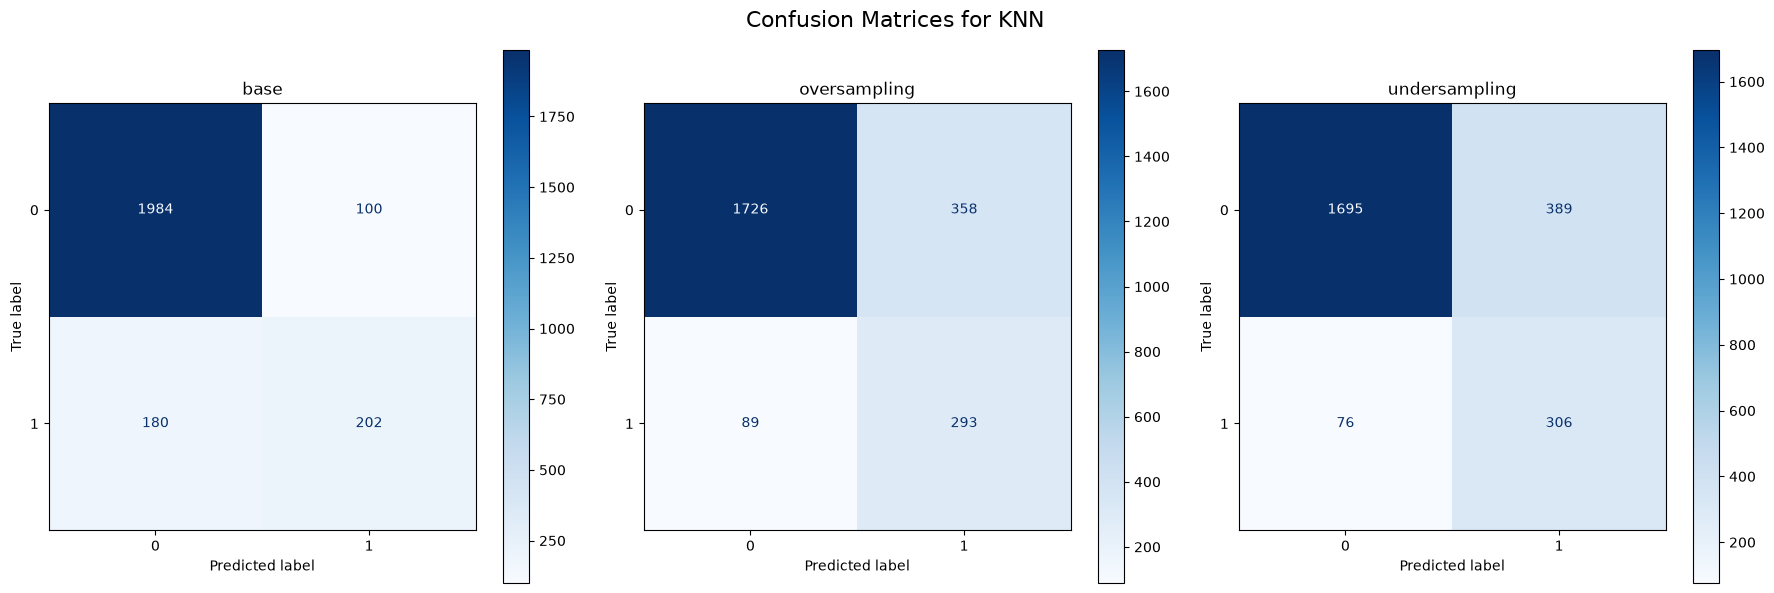

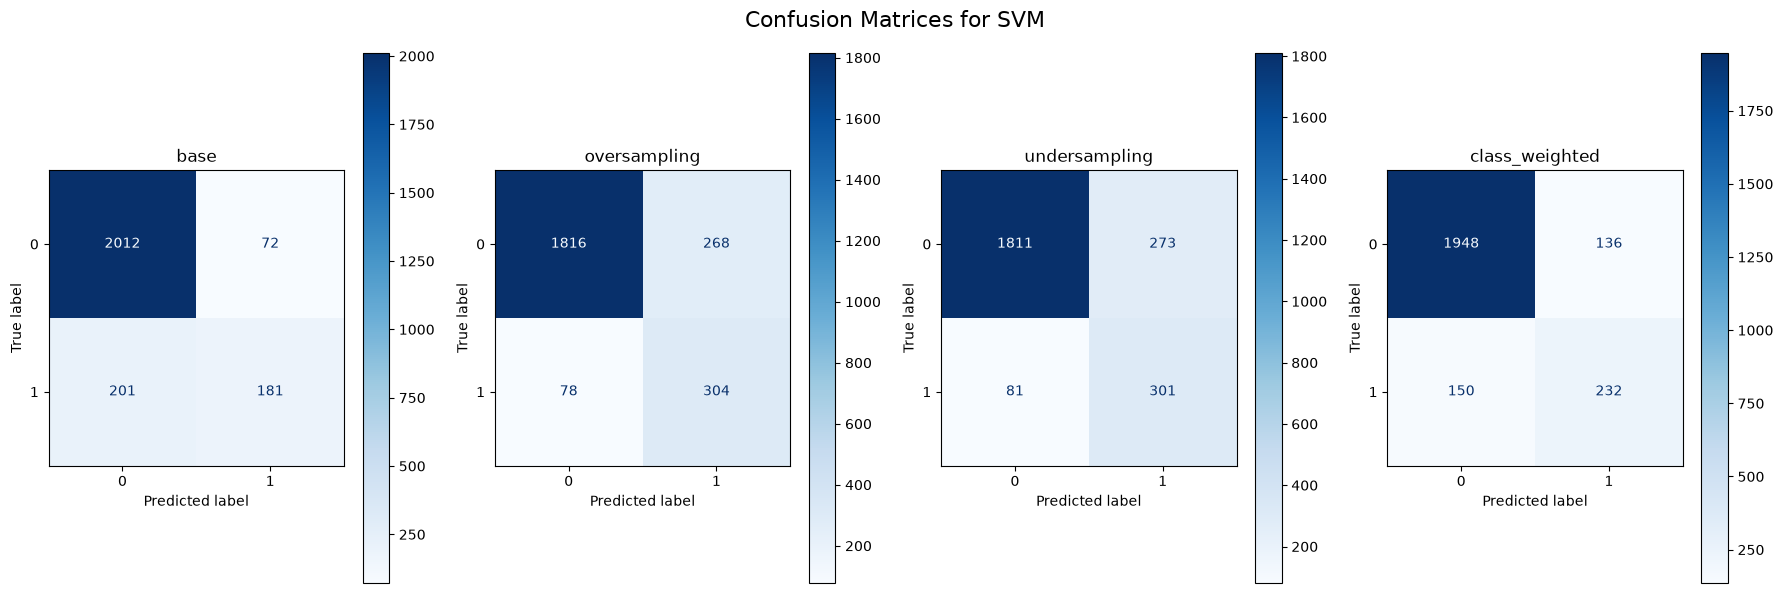

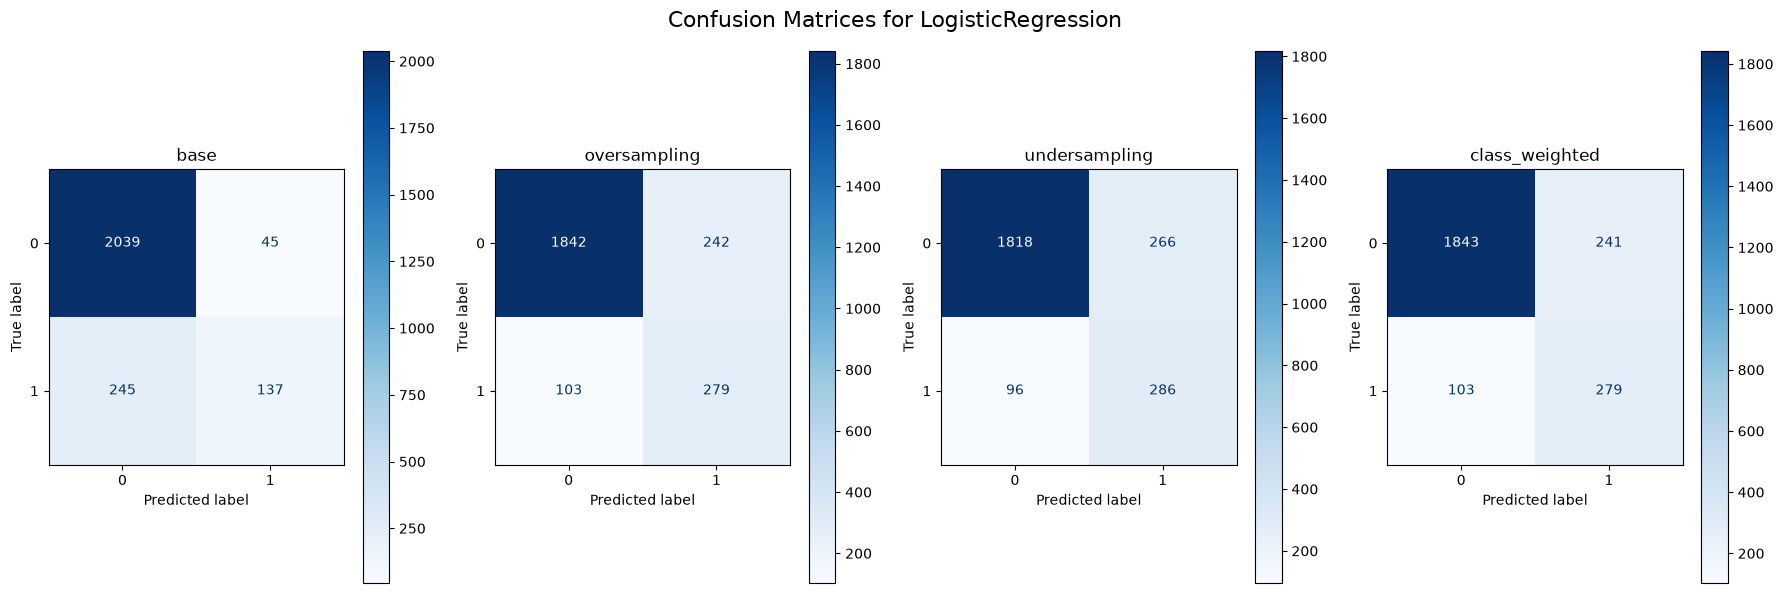

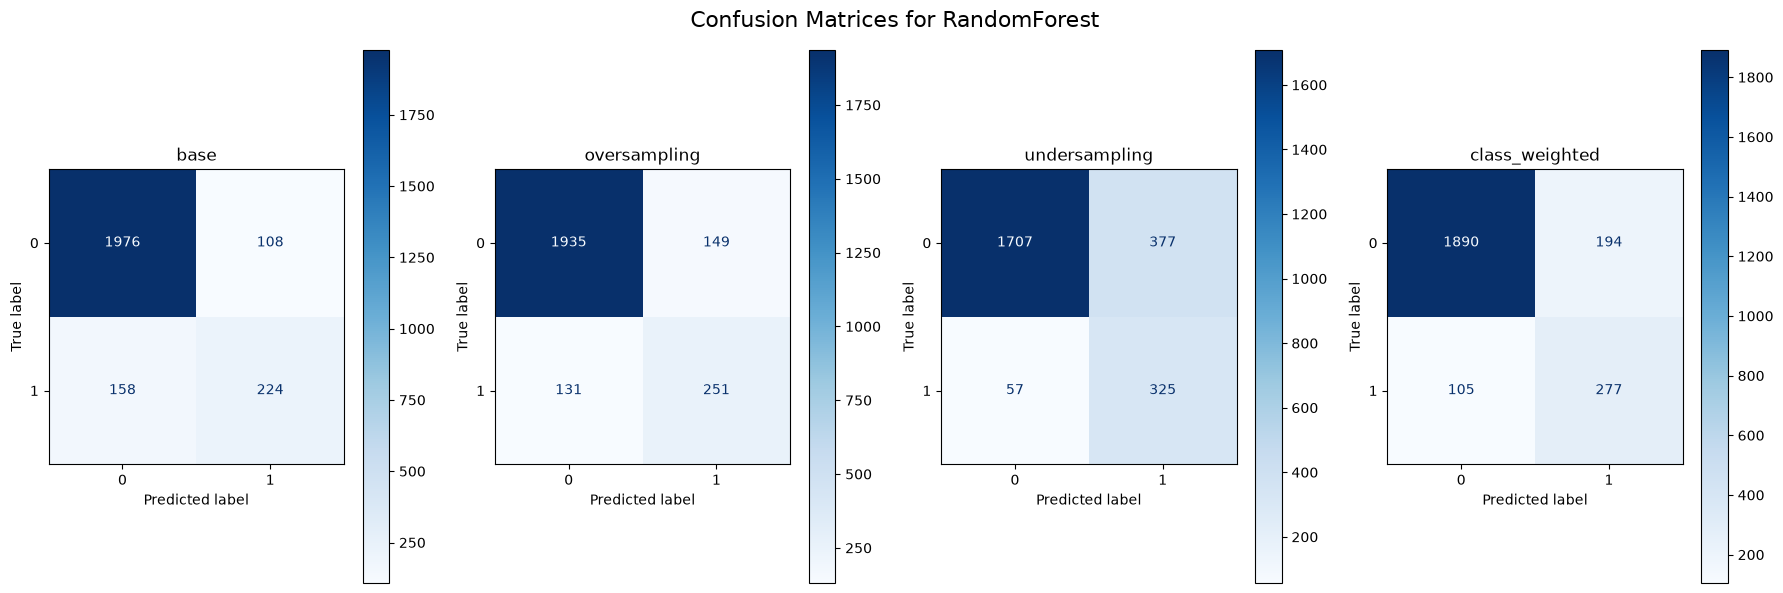

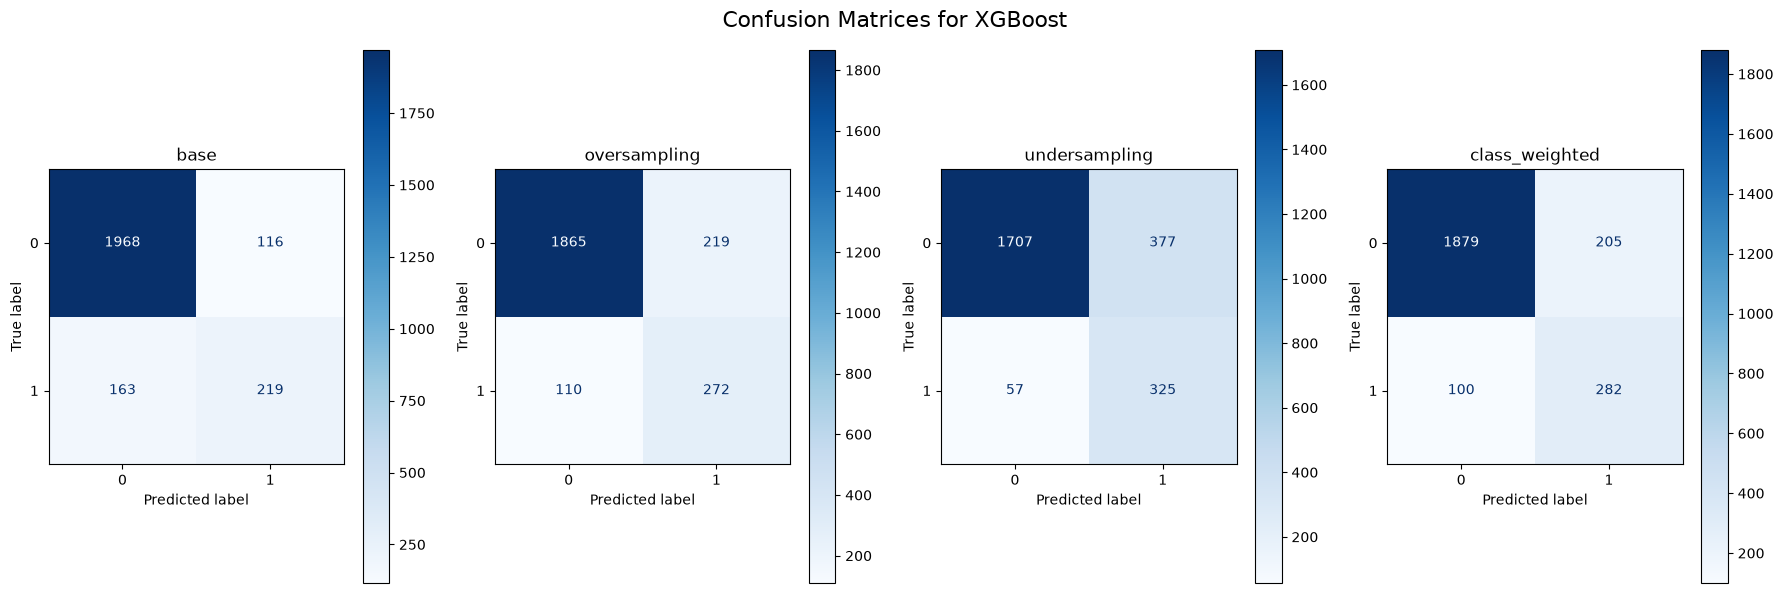

In [16]:
top10results = run_grid(
    X_train, X_test, y_train, y_test,
    select_k=config.K_BEST, tag=config.TOP10_TAG, csv_path=config.RESULTS_TOP10_CSV,
    close=False, display_full=False,
)
top10results.drop(["FPR", "TPR"], axis=1).sort_values("F1-Score", ascending=False).round(4)

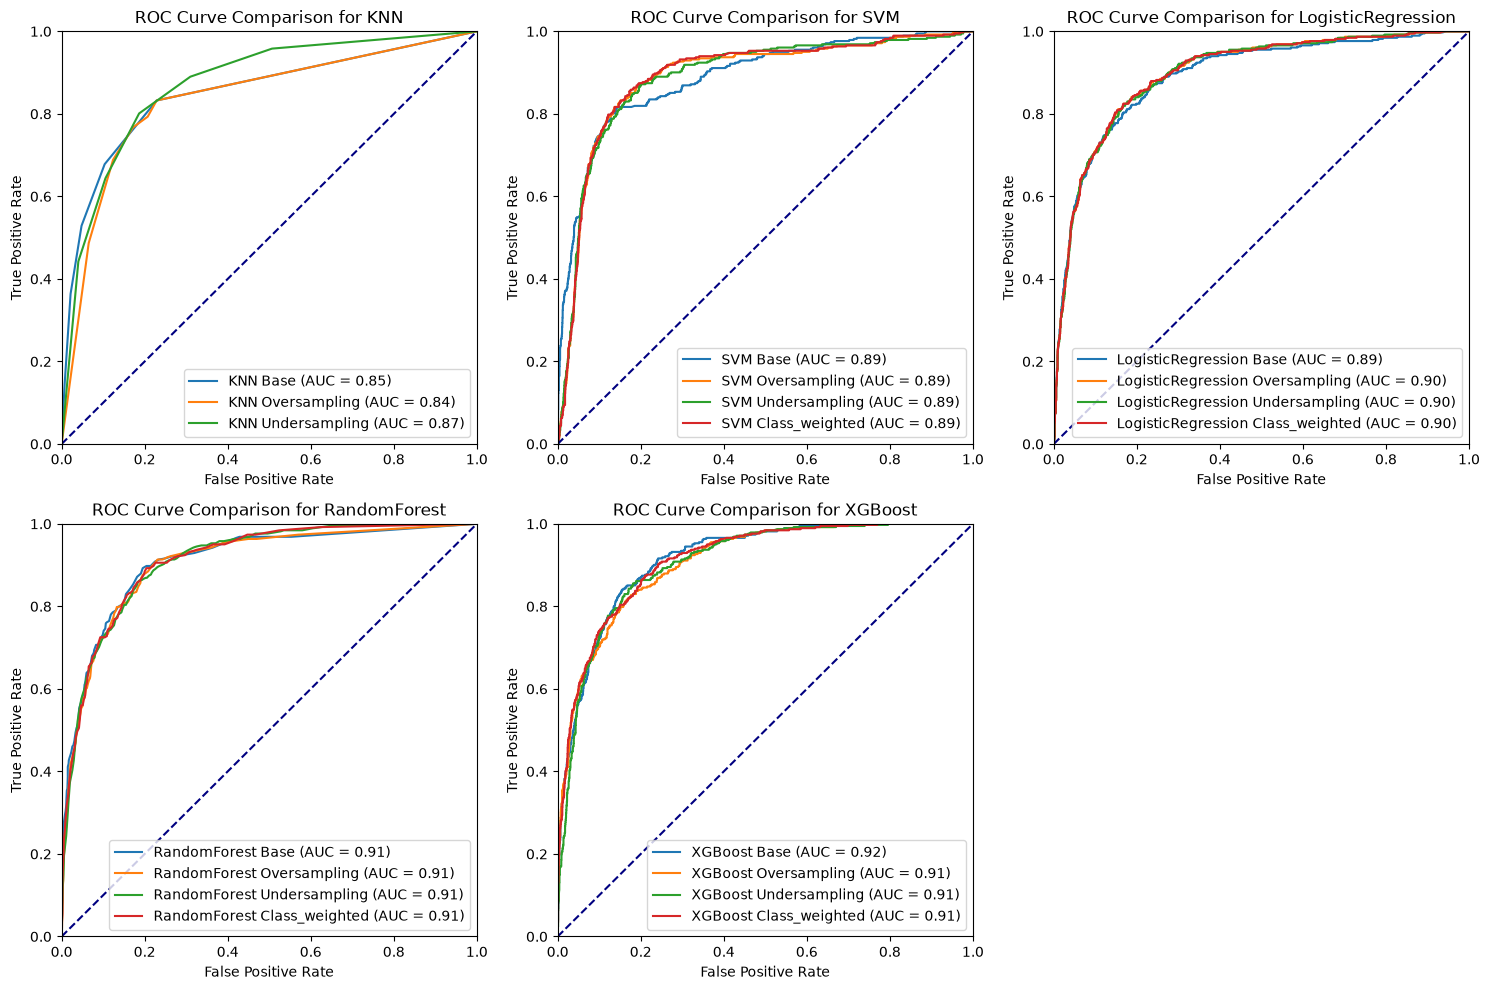

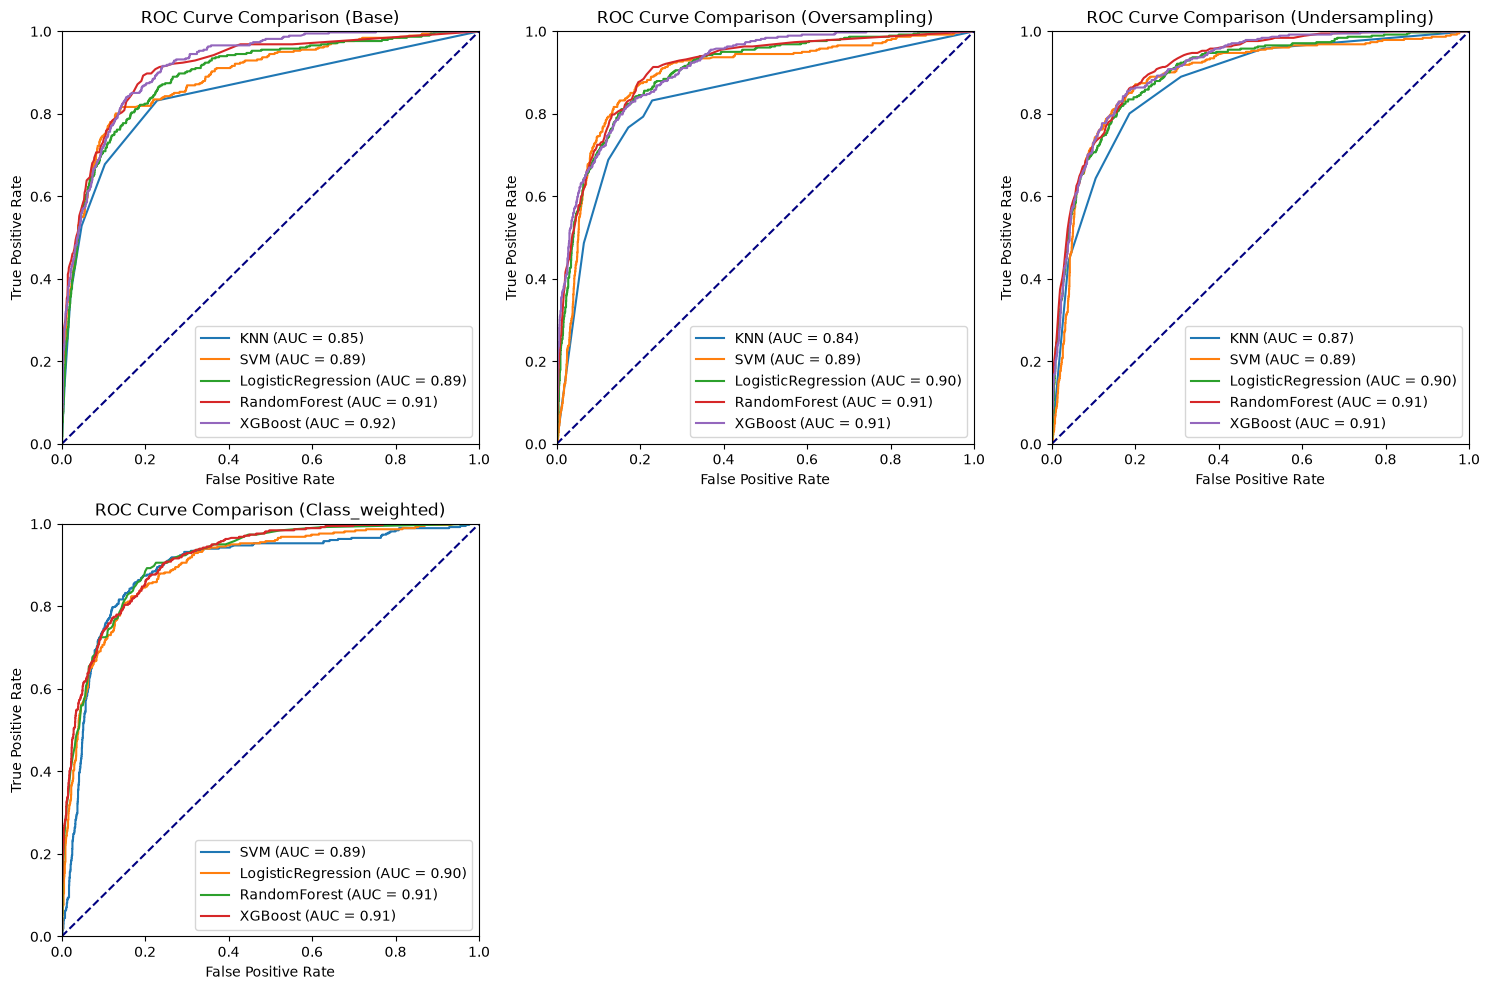

In [17]:
fig = plots_mpl.sampling_comparison(top10results, plot=False, close=False)
fig.savefig(config.IMG_DIR / "top10_roc_sampling_comparison.png")

fig = plots_mpl.model_comparison(top10results, plot=False, close=False)
fig.savefig(config.IMG_DIR / "top10_roc_model_comparison.png")

In [18]:
tune_random_forest(X_train, X_test, y_train, y_test)


Best Random Forest Parameters: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 2, 'clf__max_depth': None}
Best cross-validated F1: 0.683
Best Random Forest F1 Score (on test set): 0.659


(Pipeline(steps=[('scaler',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('scale', StandardScaler(),
                                                   <sklearn.compose._column_transformer.make_column_selector object at 0x127f0b980>)],
                                    verbose_feature_names_out=False)),
                 ('selector', 'passthrough'),
                 ('sampler', RandomOverSampler(random_state=42)),
                 ('clf',
                  RandomForestClassifier(min_samples_leaf=2, n_estimators=200,
                                         random_state=42))]),
 0.6585662211421628,
 RandomizedSearchCV(cv=5,
                    estimator=Pipeline(steps=[('scaler',
                                               ColumnTransformer(remainder='passthrough',
                                                                 transformers=[('scale',
                                                                  

In [19]:
winner = best_configuration(results)
print(
    f"Best by {config.SELECTION_METRIC} ({config.AUC_TIE_BAND:g} tie band, regime as tie-breaker): "
    f"\033[31m{winner['Model']} / {winner['SamplingTechnique']}\033[0m "
    f"\033[36m(AUC={winner['AUC']:.4f}, F1@0.5={winner['F1-Score']:.4f})\033[0m"
)

clf = classifier_registry()[winner["Model"]]
winning_pipe = build_pipeline(clf, sampler=sampler_registry()[winner["SamplingTechnique"]])
winning_pipe.fit(X_train, y_train)
y_proba = winning_pipe.predict_proba(X_test)[:, 1]

sweep_df, points = thresholds.run_sweep(y_test, y_proba)

Best by AUC (0.005 tie band, regime as tie-breaker): RandomForest / base (AUC=0.9182, F1@0.5=0.6168)

Threshold sweep [analysis-ceiling] -> data/threshold_sweep.csv
 Threshold  Accuracy  Precision   Recall  F1-Score     Lift  PredictedPositive
      0.05  0.636659   0.294728 0.965969  0.451652 1.902619               1252
      0.10  0.772506   0.398870 0.924084  0.557222 2.574905                885
      0.15  0.823601   0.463347 0.876963  0.606335 2.991136                723
      0.20  0.847526   0.504823 0.821990  0.625498 3.258885                622
      0.25  0.868208   0.552102 0.790576  0.650161 3.564095                547
      0.30  0.881995   0.593814 0.753927  0.664360 3.833368                485
      0.35  0.889700   0.625000 0.719895  0.669100 4.034686                440
      0.40  0.896594   0.665796 0.667539  0.666667 4.298047                383
      0.45  0.896188   0.690909 0.596859  0.640449 4.460162                330
      0.50  0.899838   0.738516 0.547120  0.6

In [20]:
with_pv, without_pv = run_ablation(X_train, X_test, y_train, y_test, model_name=winner["Model"], regime=winner["SamplingTechnique"])

ablation = pd.DataFrame(
    [[e[1], e[2], e[3], e[4], e[5], e[8]] for e in (with_pv, without_pv)],
    columns=["Arm", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"],
).round(4)
ablation.loc[len(ablation)] = ["delta"] + list((ablation.iloc[1, 1:] - ablation.iloc[0, 1:]).round(4))
ablation

,Arm,Accuracy,Precision,Recall,F1-Score,AUC
0,base,0.8982,0.7399,0.5288,0.6168,0.9182
1,base_ablated,0.8402,0.4211,0.0838,0.1397,0.7448
2,delta,-0.0580,-0.3188,-0.4450,-0.4771,-0.1734


In [21]:
forest = winning_pipe.named_steps["clf"]
importance = pd.Series(forest.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10).round(4)
importance

PageValues                       0.3675
SessionDuration                  0.1116
ProductRelatedAvgDuration        0.0884
AdministrativeAvgDuration        0.0764
BounceRates                      0.0699
InformationalAvgDuration         0.0373
Month_Nov                        0.0186
VisitorType_Returning_Visitor    0.0147
Weekend                          0.0138
TrafficType_2                    0.0131
dtype: float64

In [22]:
bundle = persistence.load_bundle(config.PRIMARY_BUNDLE)

bundle_metrics = {k: round(v, 4) for k, v in bundle["metadata"]["metrics"].items()}
pv_bundle_auc = round(bundle["metadata"]["pagevalues_ablation"]["auc_with"], 4)
nopv_bundle_auc = round(bundle["metadata"]["pagevalues_ablation"]["auc_without"], 4)

print(f"{"model":<17}: {bundle["metadata"]["model"]} / {bundle["metadata"]["sampling_regime"]}")
print(f"{"input features":<17}: {len(bundle["feature_order"])}")
print(f"{"headline metrics":<17}: {bundle_metrics}")
print(f"{"ablation":<17}: AUC \033[33m{pv_bundle_auc}\033[0m with PageValues, \033[32m{nopv_bundle_auc}\033[0m without")

for label, point in bundle["operating_points"].items():
    print(f"{label:<17}: t={point['threshold']:.2f} precision={point['precision']:.3f} recall={point['recall']:.3f}")

model            : RandomForest / base
input features   : 65
headline metrics : {'accuracy': 0.8982, 'precision': 0.7399, 'recall': 0.5288, 'f1': 0.6168, 'auc': 0.9182}
ablation         : AUC 0.9182 with PageValues, 0.7448 without
high_recall      : t=0.20 precision=0.505 recall=0.822
high_precision   : t=0.50 precision=0.739 recall=0.547
